# FundMap - Indian Startup Funding Analysis (2015-2022)
This notebook covers cleaning-aware EDA for the Kaggle Indian Startup Funding dataset and summarizes analyst-style business recommendations.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../Dataset/startup_funding_cleaned.csv')
df = df[df['year'].between(2015, 2022, inclusive='both')]
df = df.dropna(subset=['amount_usd'])

print('Rows:', len(df))
print('Year range in file:', int(df['year'].min()), '-', int(df['year'].max()))

Rows: 3036
Year range in file: 2015 - 2020


## 1) Funding Trend Line by Year (2015-2022)

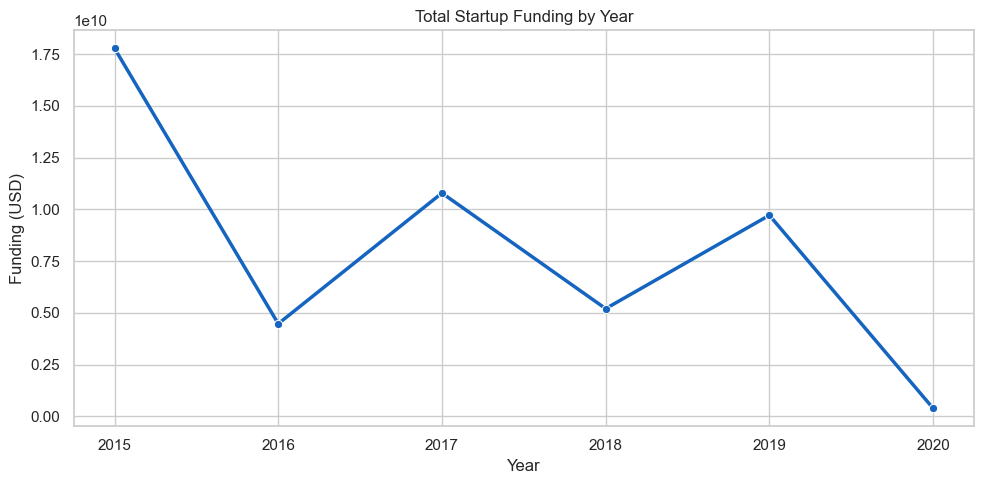

In [2]:
yearly = df.groupby('year', as_index=False)['amount_usd'].sum()
ax = sns.lineplot(data=yearly, x='year', y='amount_usd', marker='o', linewidth=2.5, color='#1565c0')
ax.set_title('Total Startup Funding by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Funding (USD)')
plt.tight_layout()
plt.show()

Insight 1: Funding volume is heavily concentrated in the later years of the dataset.
Insight 2: The provided file currently spans 2015-2020, so 2021-2022 comparisons are not available in this source.

## 2) Top 10 Sectors by Total Funding

C:\Users\jay\AppData\Local\Temp\ipykernel_33588\3443716778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_sector, x='amount_usd', y='sector_clean', palette='Blues_r')


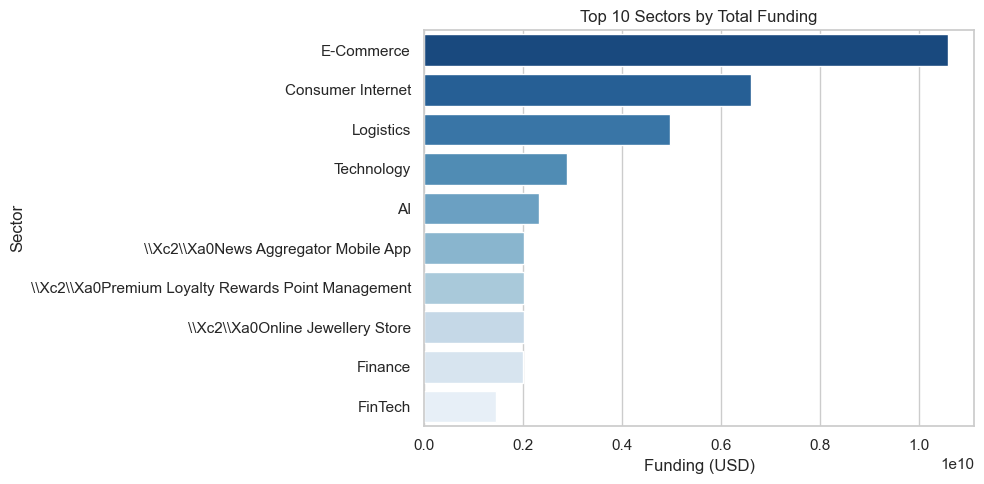

In [3]:
top_sector = df.groupby('sector_clean', as_index=False)['amount_usd'].sum().sort_values('amount_usd', ascending=False).head(10)
ax = sns.barplot(data=top_sector, x='amount_usd', y='sector_clean', palette='Blues_r')
ax.set_title('Top 10 Sectors by Total Funding')
ax.set_xlabel('Funding (USD)')
ax.set_ylabel('Sector')
plt.tight_layout()
plt.show()

Insight 1: E-Commerce and Consumer Internet are the two largest funding magnets in this dataset window.
Insight 2: Capital concentration in a few sectors indicates stronger investor conviction in digitally scalable business models.

## 3) Top 10 Cities by Total Funding

C:\Users\jay\AppData\Local\Temp\ipykernel_33588\1030207058.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_city, x='amount_usd', y='city_clean', palette='Greens_r')


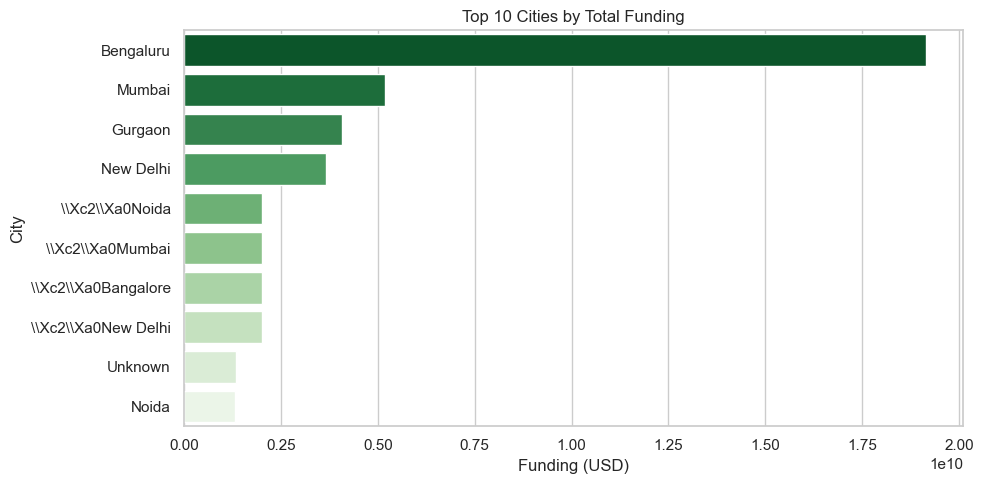

In [4]:
top_city = df.groupby('city_clean', as_index=False)['amount_usd'].sum().sort_values('amount_usd', ascending=False).head(10)
ax = sns.barplot(data=top_city, x='amount_usd', y='city_clean', palette='Greens_r')
ax.set_title('Top 10 Cities by Total Funding')
ax.set_xlabel('Funding (USD)')
ax.set_ylabel('City')
plt.tight_layout()
plt.show()

Insight 1: Bengaluru leads by a significant margin, with Mumbai and NCR cities following.
Insight 2: Funding activity remains strongly metro-centric, highlighting whitespace in non-metro ecosystems.

## 4) Heatmap: Sector vs City Funding Concentration

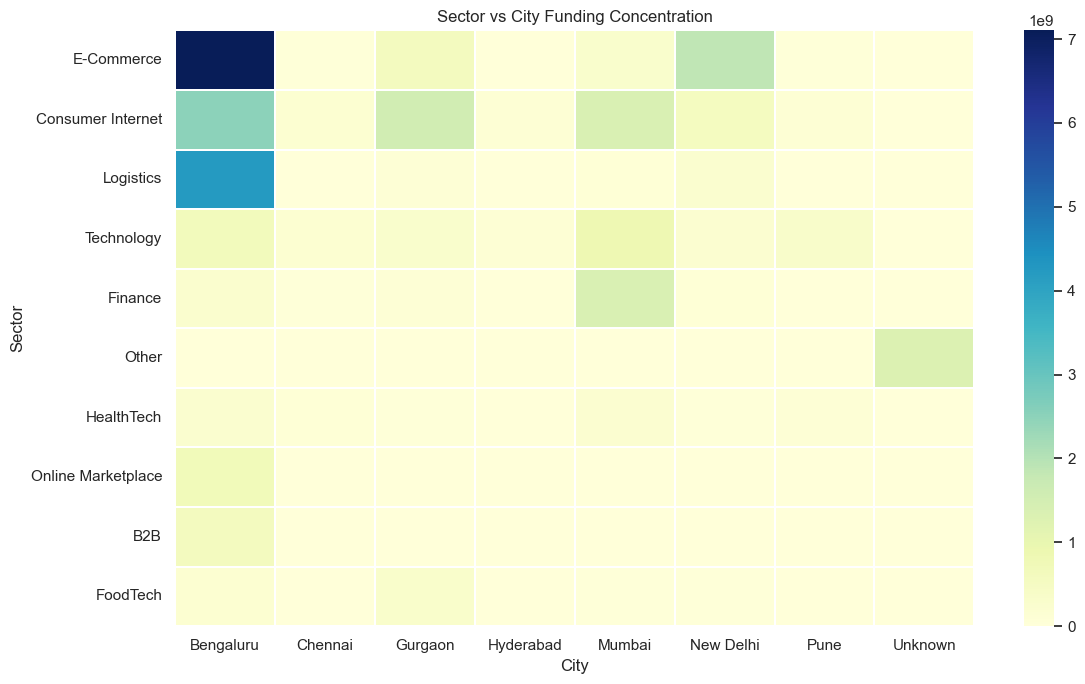

In [5]:
heat = (
    df[df['city_clean'].isin(df['city_clean'].value_counts().head(8).index)]
    .pivot_table(index='sector_clean', columns='city_clean', values='amount_usd', aggfunc='sum', fill_value=0)
)
heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).head(10).index]

plt.figure(figsize=(12, 7))
sns.heatmap(heat, cmap='YlGnBu', linewidths=0.3)
plt.title('Sector vs City Funding Concentration')
plt.xlabel('City')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

Insight 1: A few city-sector intersections account for a disproportionate share of deployed capital.
Insight 2: This concentration can help investors identify mature hubs and underpenetrated combinations.

## 5) Box Plot: Funding Amount Distribution by Stage

C:\Users\jay\AppData\Local\Temp\ipykernel_33588\2550668634.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  plot_df['stage_clean'] = pd.Categorical(plot_df['stage_clean'], categories=stage_order, ordered=True)


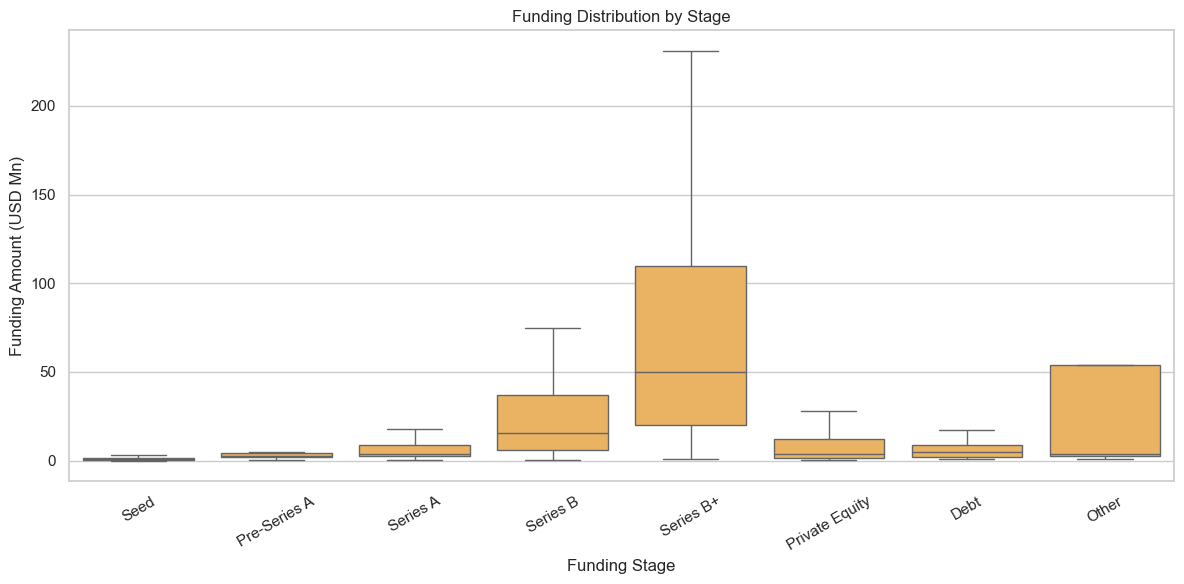

In [6]:
stage_order = ['Seed', 'Pre-Series A', 'Series A', 'Series B', 'Series B+', 'Private Equity', 'Debt', 'Other']
plot_df = df.copy()
plot_df['stage_clean'] = pd.Categorical(plot_df['stage_clean'], categories=stage_order, ordered=True)

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x='stage_clean', y='amount_usd_mn', color='#ffb74d', showfliers=False)
plt.title('Funding Distribution by Stage')
plt.xlabel('Funding Stage')
plt.ylabel('Funding Amount (USD Mn)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Insight 1: Later-stage rounds show wider spread and higher medians than early-stage rounds.
Insight 2: Deal-size volatility increases with stage maturity, especially across Series B+ and Private Equity deals.

## Final Business Recommendations

In [7]:
total_funding = df['amount_usd'].sum()
top2_sector_share = df[df['sector_clean'].isin(['E-Commerce', 'Consumer Internet'])]['amount_usd'].sum() / total_funding * 100
city_share = df[df['city_clean'].isin(['Bengaluru', 'Mumbai'])].shape[0] / len(df) * 100
series_a_2019 = df[(df['stage_clean'] == 'Series A') & (df['year'] == 2019)].shape[0]
series_a_2020 = df[(df['stage_clean'] == 'Series A') & (df['year'] == 2020)].shape[0]
series_a_growth = ((series_a_2020 - series_a_2019) / series_a_2019 * 100) if series_a_2019 else float('nan')

print(f'E-Commerce and Consumer Internet together attract {top2_sector_share:.1f}% of total funding - investors should prioritize these sectors for scale opportunities.')
print(f'Bengaluru and Mumbai together account for {city_share:.1f}% of all deals - tier-2 cities remain relatively untapped.')
print(f'Series A deals changed by {series_a_growth:.1f}% from 2019 to 2020, signaling a COVID-period shift in growth-stage risk appetite.')

E-Commerce and Consumer Internet together attract 35.6% of total funding - investors should prioritize these sectors for scale opportunities.
Bengaluru and Mumbai together account for 46.2% of all deals - tier-2 cities remain relatively untapped.
Series A deals changed by -94.7% from 2019 to 2020, signaling a COVID-period shift in growth-stage risk appetite.
